In [1]:
import geopy.distance
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sn
import numpy as np
import xarray as xr
import json
import cartopy
from datetime import datetime
from adjustText import adjust_text

## Monthly mean precipitation from GPCP

In [9]:
precipClimoMonthlyMean = xr.open_mfdataset('/Users/awing/Dropbox/ORCESTRA/TrackPlanning_precampaign/gpcpPrecipMonthlyMean.nc')
precip2024MonthlyMean = xr.open_mfdataset('/Users/awing/Dropbox/ORCESTRA/data/GPCP/GPCP_monthlymean_2024.nc')

In [6]:
precipClimoMonthlyMean

<xarray.Dataset> Size: 84kB
Dimensions:         (longitude: 51, month: 12, bnds: 2, latitude: 31)
Coordinates:
  * longitude       (longitude) float32 204B 300.0 301.0 302.0 ... 349.0 350.0
  * latitude        (latitude) float32 124B -10.0 -9.0 -8.0 ... 18.0 19.0 20.0
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: bnds
Data variables:
    longitude_bnds  (month, longitude, bnds) float32 5kB dask.array<chunksize=(12, 51, 2), meta=np.ndarray>
    latitude_bnds   (month, latitude, bnds) float32 3kB dask.array<chunksize=(12, 31, 2), meta=np.ndarray>
    precip          (month, latitude, longitude) float32 76kB dask.array<chunksize=(12, 31, 51), meta=np.ndarray>
Attributes: (12/47)
    CDI:                        Climate Data Interface version 1.9.7.1 (http:...
    history:                    Tue Nov 05 17:11:45 2019: cdo mergetime /data...
    source:                     /data1/GPCP_CDR/GPCP_Output/1DD//bin/199610/s...
    institution:                ACADEMIC > UMD/ESSIC > Earth System Science I...
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    ...                         ...
    product_version:            v01r03
    platform:                   GOES (Geostationary Operational Environmental...
    sensor:                     Imager, TOVS > TIROS Operational Vertical Sou...
    spatial_resolution:         1 degree
    comment:                    Processing computer: eagle2.umd.edu
    CDO:                        Climate Data Operators version 1.9.7.1 (http:...

In [10]:
precip2024MonthlyMean

<xarray.Dataset> Size: 84kB
Dimensions:  (time: 2, lon: 144, lat: 72)
Coordinates:
  * time     (time) datetime64[ns] 16B 2024-08-01 2024-09-01
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
Data variables:
    precip   (time, lat, lon) float32 83kB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/20)
    CDI:                   Climate Data Interface version 1.9.10 (https://mpi...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    ...                    ...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2024/08 through latest.
    CDO:                   Climate Data Operators version 1.9.10 (https://mpi...
    history:               23-Oct-2024 04:18:40 Subset NOAA/PSL

# Coordinates

### General

In [11]:
lonMin, lonMax = -60, -10
latMin, latMax = -10, 20

In [12]:
coordinates = {'mindeloNorth': 16.88, 'mindeloEast': -24.98, 'bcoNorth': 13.15, 'bcoEast': -59.42} 
latitudePirata = [-10,0,15,0,8,0,12,4,0,-6,0,-8,-14,-19,11.5,4,-6,21,20]
longitudePirata = [-10,-10,-38,-35,-38,0,-38,-38,-23,-10,-23,-30,-32,-34,-23,-23,8,-23,-38]

## Ship location as a function of time

In [13]:
DSHIP = xr.open_dataset('/Users/awing/Dropbox/ORCESTRA/data/meteor_meteo_dship_20240923.nc')

In [14]:
DSHIP

<xarray.Dataset> Size: 20MB
Dimensions:           (time: 58980)
Coordinates:
  * time              (time) datetime64[ns] 472kB 2024-08-14 ... 2024-09-23T2...
    lat               (time) float64 472kB ...
    lon               (time) float64 472kB ...
Data variables: (12/39)
    sst_port          (time) float64 472kB ...
    sst_extern_port   (time) float64 472kB ...
    sst_intern_port   (time) float64 472kB ...
    sst_board         (time) float64 472kB ...
    sst_extern_board  (time) float64 472kB ...
    sst_intern_board  (time) float64 472kB ...
    ...                ...
    ship_heave        (time) float64 472kB ...
    ship_heave_std    (time) float64 472kB ...
    ship_pitch        (time) float64 472kB ...
    ship_pitch_std    (time) float64 472kB ...
    ship_roll         (time) float64 472kB ...
    ship_roll_std     (time) float64 472kB ...

In [15]:
def calcshipHeading(shipLon,shipLat):
    dlon = np.diff(shipLon)
    shipHeading=np.empty(len(dlon))
    for hh in range(len(dlon)):
        X = np.cos(np.radians(shipLat[hh+1]))*np.sin(np.radians(dlon[hh]))
        Y = np.cos(np.radians(shipLat[hh]))*np.sin(np.radians(shipLat[hh+1]))-np.sin(np.radians(shipLat[hh]))*np.cos(np.radians(shipLat[hh+1]))*np.cos(np.radians(dlon[hh]))
        init_bearing = np.arctan2(X,Y)
        shipHeading[hh] = np.degrees(init_bearing)

    ideg = np.squeeze(np.where(shipHeading<0))
    shipHeading[ideg]=shipHeading[ideg]+360

    return shipHeading

In [16]:
#Ship track info
shipLat = DSHIP.lat
shipLon = DSHIP.lon
shipTrackTime = DSHIP.time
shipHeading = DSHIP.ship_heading
#shipHeading = calcshipHeading(shipLon,shipLat)
DSHIP.close()

In [17]:
#Calculate fraction of SEA-POL sampling at each azimuth

#hours in each track leg (hours)
#shipHeadingTime = np.diff(shipTrackTime)/60
#shipHeadingTime=shipHeadingTime.astype("float64")
shipHeadingTime=np.zeros(len(shipTrackTime)-1)+1/60 #1 minutes

#calculate range of azimuths (WRT N) sampled by SEA-POL, assuming bridge blocks 105-210 degrees with respect to shipHeading
azimuths = np.arange(0, 365, 5)
coverage = np.zeros(len(azimuths))

#radar coverage from 0 to 37
seapolstart0 = np.array(shipHeading)
seapolend0 = np.array(shipHeading)+37
ifix0 = np.squeeze(np.where(seapolend0>360))
seapolend0[ifix0]=seapolend0[ifix0]-360

#radar coverage from 45 to 105
seapolstart1 = np.array(shipHeading)+45
seapolend1 = np.array(shipHeading)+105
ifix1 = np.squeeze(np.where(seapolend1>360))
seapolend1[ifix1]=seapolend1[ifix1]-360

##radar coveage from 0 to 105
#seapolstart1 = np.array(shipHeading)
#seapolend1 = np.array(shipHeading)+105
#ifix1 = np.squeeze(np.where(seapolend1>360))
#seapolend1[ifix1]=seapolend1[ifix1]-360

#radar coverage from 210 to 360
seapolstart2 = np.array(shipHeading)-150 
seapolend2 = np.array(shipHeading)
ifix2 = np.squeeze(np.where(seapolstart2<0))
seapolstart2[ifix2]=seapolstart2[ifix2]+360

#loop over each track leg, summing up time SEA-POL sees each range of azimuths
for ht in range(len(shipHeadingTime)):

    #0 to 37 
    i0=np.squeeze(np.where(np.absolute(azimuths-seapolstart0[ht])==np.min(np.absolute(azimuths-seapolstart0[ht]))))
    i1=np.squeeze(np.where(np.absolute(azimuths-seapolend0[ht])==np.min(np.absolute(azimuths-seapolend0[ht]))))
    if i0<i1:
        coverage[i0:i1+1]=coverage[i0:i1+1]+shipHeadingTime[ht]
    else: #goes around 0
        coverage[i0:len(coverage)+1] = coverage[i0:len(coverage)+1]+shipHeadingTime[ht] #go from azimuths(i0) to 360deg
        coverage[0:i1+1] = coverage[0:i1+1]+shipHeadingTime[ht] #go from 0deg to azimuths(i1)

    #43 to 105
    i2=np.squeeze(np.where(np.absolute(azimuths-seapolstart1[ht])==np.min(np.absolute(azimuths-seapolstart1[ht]))))
    i3=np.squeeze(np.where(np.absolute(azimuths-seapolend1[ht])==np.min(np.absolute(azimuths-seapolend1[ht]))))
    if i2<i3:
        coverage[i2:i3+1]=coverage[i2:i3+1]+shipHeadingTime[ht]
    else: #goes around 0
        coverage[i2:len(coverage)+1] = coverage[i2:len(coverage)+1]+shipHeadingTime[ht] #go from azimuths(i2) to 360deg
        coverage[0:i3+1] = coverage[0:i3+1]+shipHeadingTime[ht] #go from 0deg to azimuths(i3)

    #210 to 360
    i4=np.squeeze(np.where(np.absolute(azimuths-seapolstart2[ht])==np.min(np.absolute(azimuths-seapolstart2[ht]))))
    i5=np.squeeze(np.where(np.absolute(azimuths-seapolend2[ht])==np.min(np.absolute(azimuths-seapolend2[ht]))))
    if i4<i5:
        coverage[i4:i5] = coverage[i4:i5]+shipHeadingTime[ht] #don't count shipHeading again
    else: #goes around 0
        coverage[i4:len(coverage)+1] = coverage[i4:len(coverage)+1]+shipHeadingTime[ht] #go from azimuths(i4) to 360deg
        coverage[0:i5] = coverage[0:i5]+shipHeadingTime[ht] #go from 0deg to azimuths(i5), don't count shipHeading again


######
#    i1=np.squeeze(np.where(np.absolute(azimuths-seapolstart1[ht])==np.min(np.absolute(azimuths-seapolstart1[ht]))))
#    i2=np.squeeze(np.where(np.absolute(azimuths-seapolend1[ht])==np.min(np.absolute(azimuths-seapolend1[ht]))))
#    if i1<i2:
#        coverage[i1:i2+1]=coverage[i1:i2+1]+shipHeadingTime[ht]
#    else: #goes around 0
#        coverage[i1:len(coverage)+1] = coverage[i1:len(coverage)+1]+shipHeadingTime[ht] #go from azimuths(i1) to 360deg
#        coverage[0:i2+1] = coverage[0:i2+1]+shipHeadingTime[ht] #go from 0deg to azimuths(i2)
#
#    i3=np.squeeze(np.where(np.absolute(azimuths-seapolstart2[ht])==np.min(np.absolute(azimuths-seapolstart2[ht]))))
#    i4=np.squeeze(np.where(np.absolute(azimuths-seapolend2[ht])==np.min(np.absolute(azimuths-seapolend2[ht]))))
#    if i3<i4:
#        coverage[i3:i4] = coverage[i3:i4]+shipHeadingTime[ht] #don't count shipHeading again
#    else: #goes around 0
#        coverage[i3:len(coverage)+1] = coverage[i3:len(coverage)+1]+shipHeadingTime[ht] #go from azimuths(i3) to 360deg
#        coverage[0:i4] = coverage[0:i4]+shipHeadingTime[ht] #go from 0deg to azimuths(i4), don't count shipHeading again
coverage

array([655.48333333, 669.66666667, 672.55      , 667.68333333,
       654.28333333, 617.98333333, 548.01666667, 525.98333333,
       492.08333333, 481.45      , 507.58333333, 508.01666667,
       485.2       , 537.5       , 566.93333333, 578.        ,
       592.56666667, 613.83333333, 636.01666667, 655.13333333,
       663.66666667, 658.9       , 619.91666667, 621.61666667,
       646.83333333, 661.        , 676.08333333, 716.16666667,
       732.3       , 745.46666667, 743.4       , 734.33333333,
       727.91666667, 728.51666667, 731.95      , 734.01666667,
       735.31666667, 736.2       , 732.46666667, 725.86666667,
       724.68333333, 722.16666667, 768.41666667, 828.58333333,
       845.5       , 854.23333333, 902.93333333, 898.53333333,
       905.26666667, 909.23333333, 908.26666667, 919.75      ,
       896.36666667, 898.71666667, 874.9       , 838.83333333,
       797.18333333, 803.6       , 801.58333333, 788.21666667,
       777.        , 741.11666667, 720.3       , 728.2 

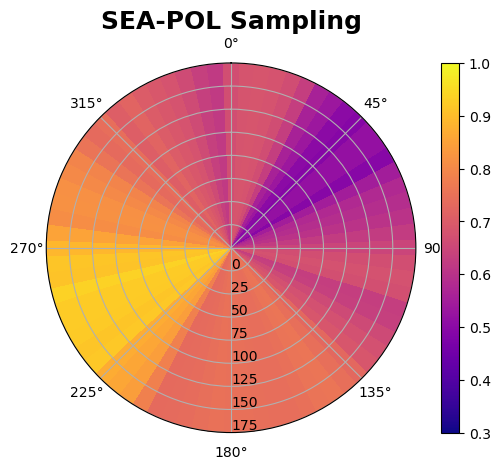

In [18]:
# Plot the SEA-POL coverage
radius = np.arange(0,151,50)
hoursTOT = np.sum(shipHeadingTime)
coverage2 = np.tile(coverage,(len(radius),1))

#polar plot
fig = plt.figure()
ax = fig.add_subplot(111,polar=True)
h1 = ax.pcolormesh(np.radians(azimuths),radius,coverage2/hoursTOT,cmap='plasma',vmin=0.3,vmax=1.0)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(180)
fig.colorbar(h1)
ax.set_title('SEA-POL Sampling',fontsize=18, weight='bold', loc='center')

plt.savefig('./figures/seapolsampling-percent.png')

In [20]:
#average august and september monthly precip
# = precipClimoMonthlyMean.mean(dim="month")
precipClimoAS = precipClimoMonthlyMean.sel(month=slice(9,10))
precipClimoASMean = precipClimoAS.mean(dim="month")
precipClimoASMean

precip2024ASMean = precip2024MonthlyMean.mean(dim="time")
precip2024ASMean

<xarray.Dataset> Size: 42kB
Dimensions:  (lon: 144, lat: 72)
Coordinates:
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
Data variables:
    precip   (lat, lon) float32 41kB dask.array<chunksize=(72, 144), meta=np.ndarray>

In [21]:
latitudePirata

[-10, 0, 15, 0, 8, 0, 12, 4, 0, -6, 0, -8, -14, -19, 11.5, 4, -6, 21, 20]

In [22]:
#planned track

planLON = [-24.98, -23, -23, -23.4, -23.4, -23.8, -32, -32, -32.4, -32.4, -32.8, -47, -47, -47.4, -47.4, -47.4, -59.42]
planLAT = [16.88, 14.5, -0.5, 14.5, 2.5, 7.5, 7.5, 14.5, 2.5, 14.5, 7.5, 7.5, 14.5, 5, 7.9, 14.9, 13.15]

Plot the ship track

/var/folders/ym/zbw7d2hd013cdrqzhhl0z7580000gn/T/ipykernel_20581/4115760582.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


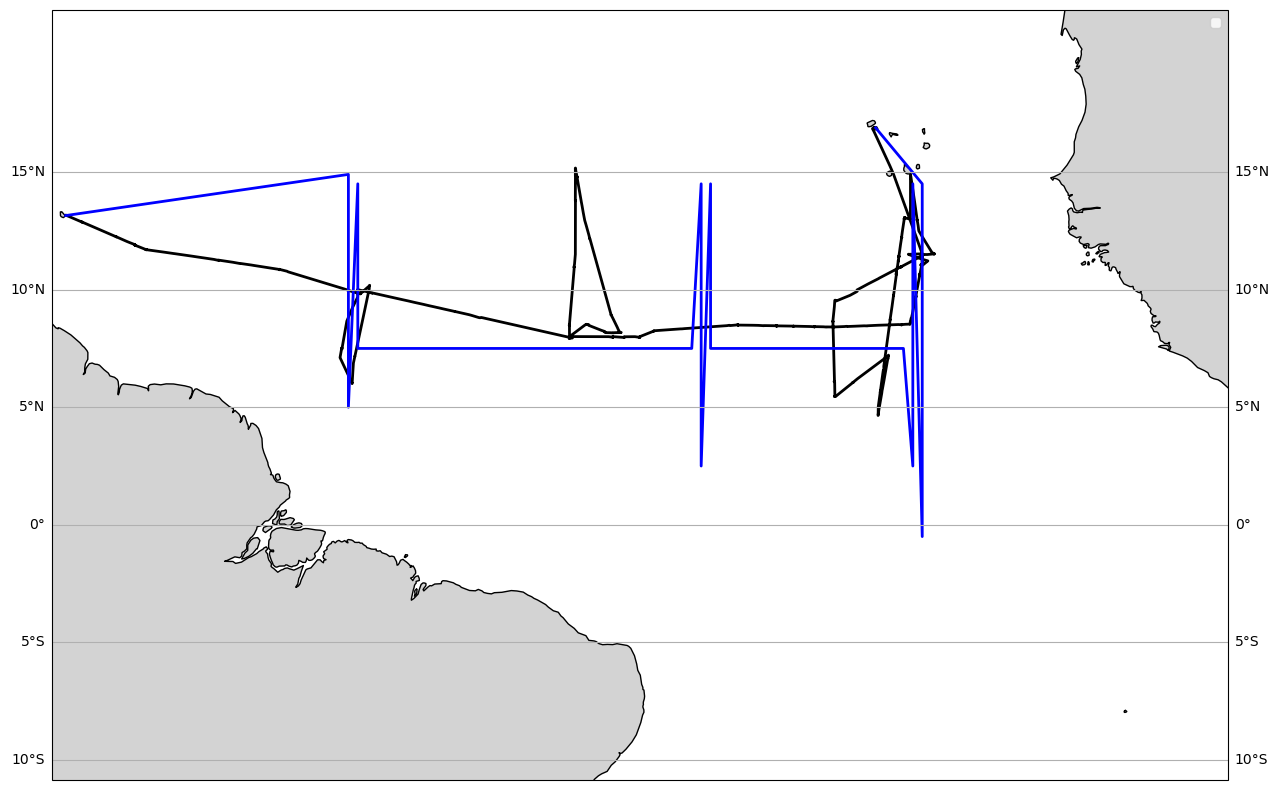

In [23]:
# create figure
fig = plt.figure(figsize=(20,10))
proj = cartopy.crs.PlateCarree()#central_longitude=offset)
ax = fig.add_subplot(111,projection=proj)

plt.plot(shipLon, shipLat, linewidth=2,color='k')
plt.plot(planLON, planLAT, linewidth=2,color='b')

# add map features
ax.add_feature(cartopy.feature.LAND,facecolor="lightgray") #land color
# ax.add_feature(cartopy.feature.OCEAN) #ocean color
ax.add_feature(cartopy.feature.COASTLINE)
# ax.add_feature(cartopy.feature.STATES)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
    xlocs=np.arange(140,190,5), ylocs=np.arange(-10,20,5))

# select plotting area
plt_area=[lonMin, lonMax, latMin, latMax] # W,E,S,N
ax.set_extent(plt_area)

plt.legend(loc="upper right")

plt.show()
plt.close()

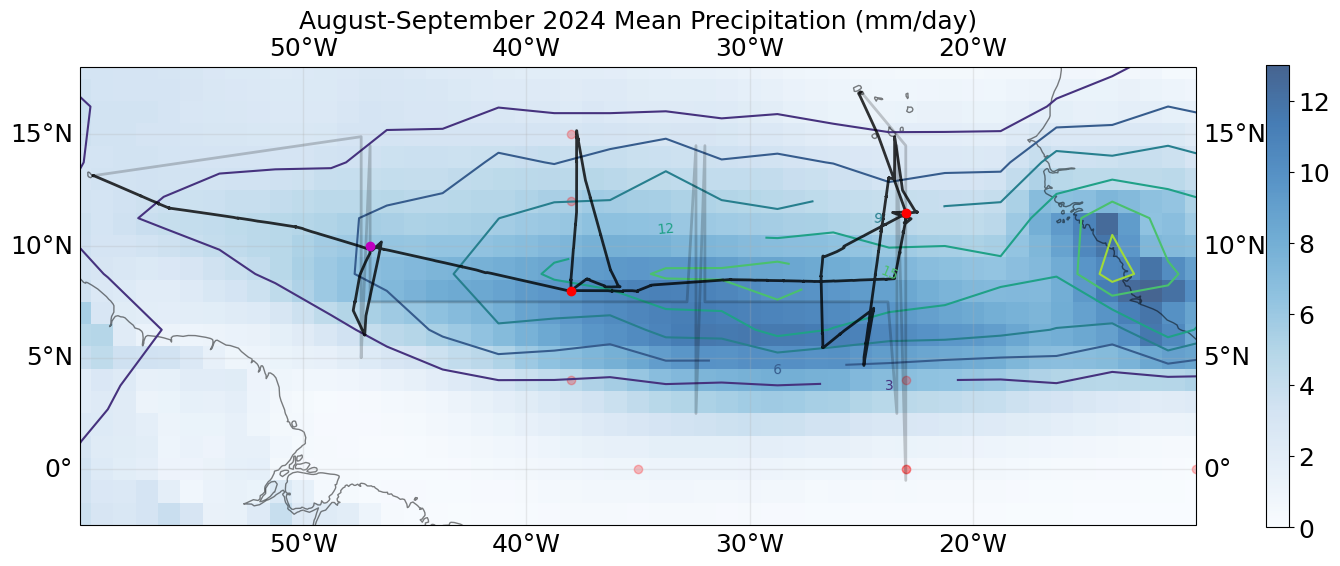

In [29]:
plt.figure(figsize = (18, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution = '50m',alpha=0.5)
#ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.25)
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=1,alpha = 0.25)
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlocator = mticker.FixedLocator([-50, -40, -30, -20])
gl.ylocator = mticker.FixedLocator([0, 5, 10, 15])
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 18}
gl.ylabel_style = {'size': 18}

plt.pcolormesh(precipClimoASMean.longitude.values-360.0, 
               precipClimoASMean.latitude.values,
               precipClimoASMean.precip.values,
               vmin = 0.0, vmax = 13, cmap = 'Blues', alpha = 0.75,
               shading='nearest')

cbar=plt.colorbar()
cbar.ax.tick_params(labelsize=18)

CS = plt.contour(precip2024ASMean.lon.values-360.0, 
               precip2024ASMean.lat.values,
               precip2024ASMean.precip.values)
ax.clabel(CS, inline=True, fontsize=10)

#plt.pcolormesh(precip2024ASMean.lon.values-360.0, 
#               precip2024ASMean.lat.values,
#               precip2024ASMean.precip.values,
#               vmin = 0.0, vmax = 13, cmap = 'Blues', alpha = 0.75,
#               shading='nearest')

#plt.title(f"August-September Climatological Mean Precipitation (mm/day)",size=18)
plt.title("August-September 2024 Mean Precipitation (mm/day)",size=18)

ax.set_xlim(lonMin, lonMax)
ax.set_ylim(-2.5, 18)

#plt.scatter(shipLon,shipLat, alpha=0.8, color = 'k', marker = 'X')
p1 = plt.plot(shipLon,shipLat, alpha=0.8, color = 'k',linewidth= 2)
p2 = plt.plot(planLON,planLAT, alpha=0.2, color = 'k',linewidth= 2)

plt.scatter(longitudePirata[0:4], latitudePirata[0:4], color = 'r', label = 'PIRATA', alpha = 0.25)
plt.plot(longitudePirata[4], latitudePirata[4], color = 'r', label = 'PIRATA', alpha = 1.0,marker='o',markersize=6)
plt.scatter(longitudePirata[5:14], latitudePirata[5:14], color = 'r', label = 'PIRATA', alpha = 0.25)
plt.plot(longitudePirata[14], latitudePirata[14], color = 'r', label = 'PIRATA', alpha = 1.0,marker='o',markersize=6)
plt.scatter(longitudePirata[14:20], latitudePirata[14:20], color = 'r', label = 'PIRATA', alpha = 0.25)
plt.plot(-47, 10, color = 'm', alpha = 1.0,marker='o',markersize=6)
#plt.plot(coordinates['bcoEast'], coordinates['bcoNorth'], marker = 'X',markersize=10)

#texts = []
#for x, y, s in zip(shipLon, shipLat, shipTrackTime):
#    #texts.append(plt.text(x, y, str(s)[5:-3], color = 'k', fontsize = 14, backgroundcolor='white', bbox=dict(facecolor='white', alpha=0.6, linewidth=0, pad=1.0)))
#    texts.append(plt.text(x, y, str(s)[5:-3], color = 'k', fontsize = 14))
#adjust_text(texts, longitudePirata+list(shipLon), latitudePirata+list(shipLat), force_text = (1.5, 0.5))
#sn.despine()

#plt.savefig('./figures/Meteor_track_actual.png')